# Step 0: Overview

- Goal: compare ML strategies vs rule-based benchmarks on hourly crypto data.
- Scope: BTC/ETH/XRP/SOL, 2021-2025, transaction-cost-aware backtest in notebook simulation.
- Workflow: Step 1 data+features -> Step 2 modeling/tuning -> Step 3 backtest -> Step 4 evaluation.


# Step 1: Data Import and Feature Engineering

This notebook section implements Step 1:
- import hourly Binance-like data
- clean and standardize schema
- create OHLC/candlestick/technical features
- create next-hour direction label

Notes:
- This is for course-project backtesting simulation only.
- Features are constructed using past information only.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# ------------------------------
# Configuration
# ------------------------------
DATA_DIR = Path('data/raw')
OUTPUT_DIR = Path('data/features')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ASSETS = ['BTCUSDT', 'ETHUSDT', 'XRPUSDT', 'SOLUSDT']

# Optional explicit mapping if your filenames are not auto-detected.
# Example:
# FILE_MAP = {
#     'BTCUSDT': 'BTCUSDT_1h.csv',
#     'ETHUSDT': 'ETHUSDT_1h.csv',
#     'XRPUSDT': 'XRPUSDT_1h.csv',
#     'SOLUSDT': 'SOLUSDT_1h.csv',
# }
FILE_MAP = {}


In [3]:
# ------------------------------
# Helpers: loading and cleaning
# ------------------------------
RENAME_MAP = {
    'open_time': 'timestamp',
    'Open time': 'timestamp',
    'date': 'timestamp',
    'datetime': 'timestamp',
    'time': 'timestamp',
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Close': 'close',
    'Volume': 'volume',
    'Number of trades': 'trades',
    'trade_count': 'trades',
    'number_of_trades': 'trades'
}


def find_asset_file(asset: str) -> Path:
    if asset in FILE_MAP:
        f = DATA_DIR / FILE_MAP[asset]
        if not f.exists():
            raise FileNotFoundError(f'Configured file not found: {f}')
        return f

    candidates = sorted([f for f in DATA_DIR.glob('*.csv') if asset in f.name.upper()])
    if not candidates:
        raise FileNotFoundError(f'No CSV file found for {asset} in {DATA_DIR}')
    return candidates[0]


def parse_timestamp_column(ts: pd.Series) -> pd.Series:
    # Handle mixed epoch units (s/ms/us/ns) robustly.
    s = pd.to_numeric(ts, errors='coerce')

    # If mostly non-numeric, parse as datetime strings.
    if s.notna().mean() < 0.95:
        return pd.to_datetime(ts, utc=True, errors='coerce')

    out = pd.Series(pd.NaT, index=ts.index, dtype='datetime64[ns, UTC]')
    masks = {
        's': s.between(1e9, 1e10, inclusive='left'),
        'ms': s.between(1e12, 1e13, inclusive='left'),
        'us': s.between(1e15, 1e16, inclusive='left'),
        'ns': s.between(1e18, 1e19, inclusive='left')
    }

    for unit, mask in masks.items():
        if mask.any():
            out.loc[mask] = pd.to_datetime(s.loc[mask], unit=unit, utc=True, errors='coerce')

    unresolved = out.isna() & s.notna()
    if unresolved.any():
        out.loc[unresolved] = pd.to_datetime(ts.loc[unresolved], utc=True, errors='coerce')

    return out


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns=RENAME_MAP).copy()

    required = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}. Found: {list(df.columns)}')

    if 'trades' not in df.columns:
        df['trades'] = np.nan

    keep = ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'trades']
    df = df[keep].copy()

    df['timestamp'] = parse_timestamp_column(df['timestamp'])

    numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'trades']
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df = df.dropna(subset=['timestamp', 'open', 'high', 'low', 'close'])
    df = df.sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)
    return df


def load_asset_data(asset: str) -> pd.DataFrame:
    file_path = find_asset_file(asset)
    raw = pd.read_csv(file_path)
    clean = standardize_columns(raw)
    clean['asset'] = asset
    return clean


In [4]:
# ------------------------------
# Helpers: feature engineering
# ------------------------------
def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)

    avg_gain = gain.ewm(alpha=1/window, adjust=False, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1/window, adjust=False, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def compute_macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    macd_hist = macd_line - signal_line
    return macd_line, signal_line, macd_hist


def create_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Basic returns
    out['ret_1h'] = out['close'].pct_change()
    out['log_ret_1h'] = np.log(out['close'] / out['close'].shift(1))

    # Candlestick features
    out['body'] = (out['close'] - out['open']).abs()
    out['upper_shadow'] = out['high'] - out[['open', 'close']].max(axis=1)
    out['lower_shadow'] = out[['open', 'close']].min(axis=1) - out['low']
    out['direction'] = np.where(out['close'] >= out['open'], 1, -1)
    out['hl_range'] = out['high'] - out['low']

    # Technical indicators
    out['sma_12'] = out['close'].rolling(12, min_periods=12).mean()
    out['sma_24'] = out['close'].rolling(24, min_periods=24).mean()
    out['rsi_14'] = compute_rsi(out['close'], window=14)
    macd_line, signal_line, macd_hist = compute_macd(out['close'])
    out['macd'] = macd_line
    out['macd_signal'] = signal_line
    out['macd_hist'] = macd_hist

    # Next-hour prediction target
    out['next_ret_1h'] = out['close'].shift(-1) / out['close'] - 1
    out['label_up_1h'] = (out['next_ret_1h'] > 0).astype(int)

    # Keep only rows with complete features and labels
    feature_cols = [
        'open', 'high', 'low', 'close', 'volume', 'trades',
        'ret_1h', 'log_ret_1h',
        'body', 'upper_shadow', 'lower_shadow', 'direction', 'hl_range',
        'sma_12', 'sma_24', 'rsi_14', 'macd', 'macd_signal', 'macd_hist',
        'next_ret_1h', 'label_up_1h'
    ]
    out = out.dropna(subset=feature_cols).reset_index(drop=True)
    return out


In [5]:
# ------------------------------
# Run Step 2 for all assets
# ------------------------------
processed = {}
summary_rows = []

for asset in ASSETS:
    df_raw = load_asset_data(asset)
    df_feat = create_features(df_raw)
    processed[asset] = df_feat

    out_path = OUTPUT_DIR / f'{asset}_features.csv'
    df_feat.to_csv(out_path, index=False)

    summary_rows.append({
        'asset': asset,
        'raw_rows': len(df_raw),
        'feature_rows': len(df_feat),
        'start_ts': df_feat['timestamp'].min() if len(df_feat) else pd.NaT,
        'end_ts': df_feat['timestamp'].max() if len(df_feat) else pd.NaT,
        'output_file': str(out_path)
    })

summary = pd.DataFrame(summary_rows)
summary


,asset,raw_rows,feature_rows,start_ts,end_ts,output_file
0,BTCUSDT,43810,43786,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,data\features\BTCUSDT_features.csv
1,ETHUSDT,43810,43786,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,data\features\ETHUSDT_features.csv
2,XRPUSDT,43810,43786,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,data\features\XRPUSDT_features.csv
3,SOLUSDT,43810,43786,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,data\features\SOLUSDT_features.csv


In [6]:
# Quick inspection example
example_asset = ASSETS[0]
processed[example_asset].head()


,timestamp,open,high,low,close,volume,trades,asset,ret_1h,log_ret_1h,...,direction,hl_range,sma_12,sma_24,rsi_14,macd,macd_signal,macd_hist,next_ret_1h,label_up_1h
0,2021-01-01 23:00:00+00:00,29262.32,29338.89,29228.14,29331.69,971.123385,28620,BTCUSDT,0.002371,0.002368,...,1,110.75,29221.008333,29206.012500,76.978032,33.520552,34.148839,-0.628288,-0.004576,0
1,2021-01-02 00:00:00+00:00,29331.70,29338.59,28946.53,29197.48,2638.159379,56787,BTCUSDT,-0.004576,-0.004586,...,-1,392.06,29218.007500,29214.443750,72.381062,30.173454,33.353762,-3.180308,0.005548,1
2,2021-01-02 01:00:00+00:00,29197.93,29400.00,29100.00,29359.47,1891.997249,41136,BTCUSDT,0.005548,0.005533,...,1,300.00,29209.230833,29212.338750,74.370511,40.129506,34.708911,5.420595,-0.001214,0
3,2021-01-02 02:00:00+00:00,29359.46,29469.00,29320.01,29323.82,1704.830137,34864,BTCUSDT,-0.001214,-0.001215,...,-1,148.99,29208.895833,29217.720833,73.122176,44.628641,36.692857,7.935784,0.000959,1
4,2021-01-02 03:00:00+00:00,29323.82,29382.49,29256.85,29351.95,1158.041761,33338,BTCUSDT,0.000959,0.000959,...,1,125.64,29222.502500,29220.785417,73.500156,49.889005,39.332087,10.556918,-0.000079,0


## Step 1 Data Structure Inspection

Use this block to understand what the cleaned/featured dataset looks like before modeling.


In [7]:
if 'processed' not in globals():
    raise RuntimeError('Run Step 1 processing cells first.')

example_asset = ASSETS[0]
df = processed[example_asset].copy()

print(f'Asset: {example_asset}')
print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')
print('Timestamp range:', df['timestamp'].min(), '->', df['timestamp'].max())

print('\nColumns:')
print(list(df.columns))

print('\nDtypes:')
display(df.dtypes.to_frame('dtype'))

print('\nMissing values by column (example asset):')
display(df.isna().sum().to_frame('missing_count'))

print('\nFirst 5 rows:')
display(df.head())

print('\nNumeric summary (example asset):')
display(df.describe().T)

# Compact multi-asset structure summary
rows = []
for asset, d in processed.items():
    rows.append({
        'asset': asset,
        'rows': len(d),
        'cols': d.shape[1],
        'start_ts': d['timestamp'].min(),
        'end_ts': d['timestamp'].max(),
        'missing_total': int(d.isna().sum().sum())
    })

structure_df = pd.DataFrame(rows)
print('\nStructure overview across assets:')
display(structure_df)


Asset: BTCUSDT
Rows: 43,786 | Columns: 23
Timestamp range: 2021-01-01 23:00:00+00:00 -> 2025-12-31 22:00:00+00:00

Columns:
['timestamp', 'open', 'high', 'low', 'close', 'volume', 'trades', 'asset', 'ret_1h', 'log_ret_1h', 'body', 'upper_shadow', 'lower_shadow', 'direction', 'hl_range', 'sma_12', 'sma_24', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'next_ret_1h', 'label_up_1h']

Dtypes:


,dtype
timestamp,"datetime64[ns, UTC]"
open,float64
high,float64
low,float64
close,float64
volume,float64
trades,int64
asset,object
ret_1h,float64
log_ret_1h,float64



Missing values by column (example asset):


,missing_count
timestamp,0
open,0
high,0
low,0
close,0
volume,0
trades,0
asset,0
ret_1h,0
log_ret_1h,0



First 5 rows:


,timestamp,open,high,low,close,volume,trades,asset,ret_1h,log_ret_1h,...,direction,hl_range,sma_12,sma_24,rsi_14,macd,macd_signal,macd_hist,next_ret_1h,label_up_1h
0,2021-01-01 23:00:00+00:00,29262.32,29338.89,29228.14,29331.69,971.123385,28620,BTCUSDT,0.002371,0.002368,...,1,110.75,29221.008333,29206.012500,76.978032,33.520552,34.148839,-0.628288,-0.004576,0
1,2021-01-02 00:00:00+00:00,29331.70,29338.59,28946.53,29197.48,2638.159379,56787,BTCUSDT,-0.004576,-0.004586,...,-1,392.06,29218.007500,29214.443750,72.381062,30.173454,33.353762,-3.180308,0.005548,1
2,2021-01-02 01:00:00+00:00,29197.93,29400.00,29100.00,29359.47,1891.997249,41136,BTCUSDT,0.005548,0.005533,...,1,300.00,29209.230833,29212.338750,74.370511,40.129506,34.708911,5.420595,-0.001214,0
3,2021-01-02 02:00:00+00:00,29359.46,29469.00,29320.01,29323.82,1704.830137,34864,BTCUSDT,-0.001214,-0.001215,...,-1,148.99,29208.895833,29217.720833,73.122176,44.628641,36.692857,7.935784,0.000959,1
4,2021-01-02 03:00:00+00:00,29323.82,29382.49,29256.85,29351.95,1158.041761,33338,BTCUSDT,0.000959,0.000959,...,1,125.64,29222.502500,29220.785417,73.500156,49.889005,39.332087,10.556918,-0.000079,0



Numeric summary (example asset):


,count,mean,std,min,25%,50%,75%,max
open,43786.0,54403.987742,29463.450425,15648.230000,29406.677500,46526.145000,69073.502500,1.260112e+05
high,43786.0,54617.285758,29536.902063,15769.990000,29470.527500,46752.145000,69296.770000,1.261996e+05
low,43786.0,54181.333949,29387.325529,15476.000000,29350.000000,46247.425000,68823.035000,1.252527e+05
close,43786.0,54405.324187,29463.635898,15649.520000,29408.755000,46527.985000,69073.912500,1.260112e+05
volume,43786.0,3109.779739,4724.653626,0.000000,749.898600,1476.722740,3339.288255,1.372072e+05
trades,43786.0,118429.464943,123443.198004,0.000000,41848.000000,74279.500000,148347.000000,3.520247e+06
ret_1h,43786.0,0.000046,0.006414,-0.089545,-0.002318,0.000046,0.002480,1.231590e-01
log_ret_1h,43786.0,0.000025,0.006417,-0.093810,-0.002321,0.000046,0.002477,1.161452e-01
body,43786.0,206.147618,272.282159,0.000000,43.252500,115.310000,261.645000,5.142300e+03
upper_shadow,43786.0,109.555984,133.266086,0.000000,25.340000,66.660000,146.140000,2.650980e+03



Structure overview across assets:


,asset,rows,cols,start_ts,end_ts,missing_total
0,BTCUSDT,43786,23,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,0
1,ETHUSDT,43786,23,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,0
2,XRPUSDT,43786,23,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,0
3,SOLUSDT,43786,23,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,0


## Step 1 Validation Visualizations

These plots check whether Step 1 matches the proposal:
- 4 assets, hourly data, 2021-2025 coverage
- clean and continuous time index
- OHLC/candlestick/indicator features created correctly
- next-hour label constructed and reasonable


In [8]:
from IPython.display import display
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


,asset,raw_rows,feature_rows,start_ts,end_ts,output_file
0,BTCUSDT,43810,43786,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,data\features\BTCUSDT_features.csv
1,ETHUSDT,43810,43786,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,data\features\ETHUSDT_features.csv
2,XRPUSDT,43810,43786,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,data\features\XRPUSDT_features.csv
3,SOLUSDT,43810,43786,2021-01-01 23:00:00+00:00,2025-12-31 22:00:00+00:00,data\features\SOLUSDT_features.csv


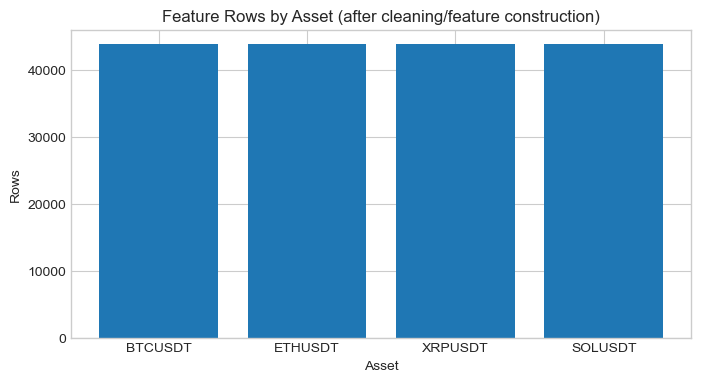

In [9]:
# 1) Coverage and row count by asset
if 'summary' not in globals():
    raise RuntimeError('Run Step 1 cells first to build `summary` and `processed`.')

display(summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary['asset'], summary['feature_rows'])
ax.set_title('Feature Rows by Asset (after cleaning/feature construction)')
ax.set_ylabel('Rows')
ax.set_xlabel('Asset')
plt.show()


C:\Users\wilbe\AppData\Local\Temp\ipykernel_15980\1332724824.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full = pd.date_range(start=ts.min(), end=ts.max(), freq='1H', tz='UTC')
C:\Users\wilbe\AppData\Local\Temp\ipykernel_15980\1332724824.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full = pd.date_range(start=ts.min(), end=ts.max(), freq='1H', tz='UTC')
C:\Users\wilbe\AppData\Local\Temp\ipykernel_15980\1332724824.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full = pd.date_range(start=ts.min(), end=ts.max(), freq='1H', tz='UTC')
C:\Users\wilbe\AppData\Local\Temp\ipykernel_15980\1332724824.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full = pd.date_range(start=ts.min(), end=ts.max(), freq='1H', tz='UTC')


,asset,missing_hours,expected_hours,actual_rows
0,BTCUSDT,14,43800,43786
1,ETHUSDT,14,43800,43786
2,XRPUSDT,14,43800,43786
3,SOLUSDT,14,43800,43786


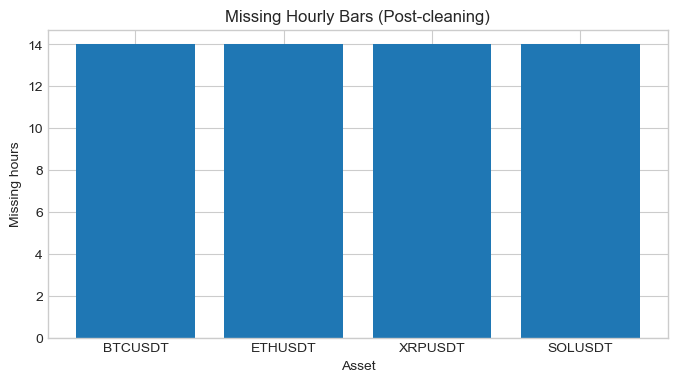

In [10]:
# 2) Time continuity check: missing hourly bars per asset
missing_info = []
for asset, df in processed.items():
    ts = pd.to_datetime(df['timestamp'], utc=True)
    full = pd.date_range(start=ts.min(), end=ts.max(), freq='1H', tz='UTC')
    missing = len(full.difference(ts))
    missing_info.append({'asset': asset, 'missing_hours': missing, 'expected_hours': len(full), 'actual_rows': len(ts)})

missing_df = pd.DataFrame(missing_info)
display(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(missing_df['asset'], missing_df['missing_hours'])
ax.set_title('Missing Hourly Bars (Post-cleaning)')
ax.set_ylabel('Missing hours')
ax.set_xlabel('Asset')
plt.show()


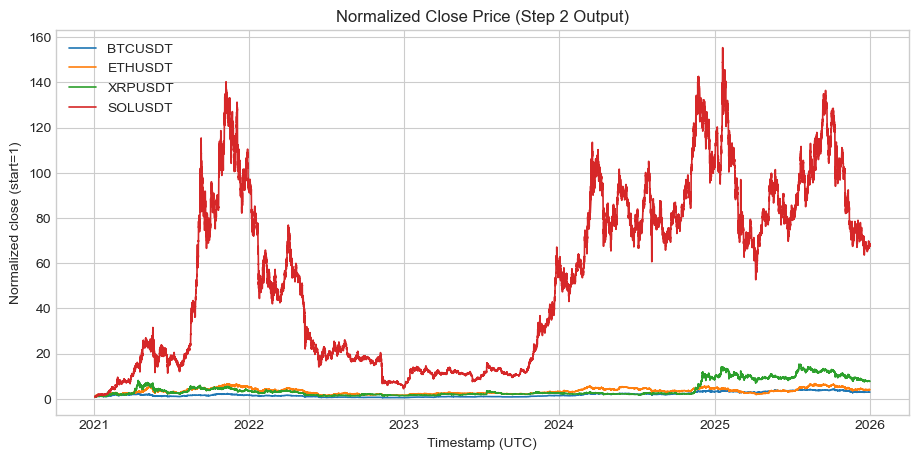

In [11]:
# 3) Price history (normalized close) for cross-asset comparison
fig, ax = plt.subplots(figsize=(11, 5))
for asset, df in processed.items():
    ts = pd.to_datetime(df['timestamp'], utc=True)
    norm_close = df['close'] / df['close'].iloc[0]
    ax.plot(ts, norm_close, label=asset, linewidth=1.2)

ax.set_title('Normalized Close Price (Step 2 Output)')
ax.set_ylabel('Normalized close (start=1)')
ax.set_xlabel('Timestamp (UTC)')
ax.legend()
plt.show()


,asset,body_nonneg_pct,upper_shadow_nonneg_pct,lower_shadow_nonneg_pct,body_le_hl_range_pct
0,BTCUSDT,1.0,1.0,1.0,1.0
1,ETHUSDT,1.0,1.0,1.0,1.0
2,XRPUSDT,1.0,1.0,1.0,1.0
3,SOLUSDT,1.0,1.0,1.0,1.0


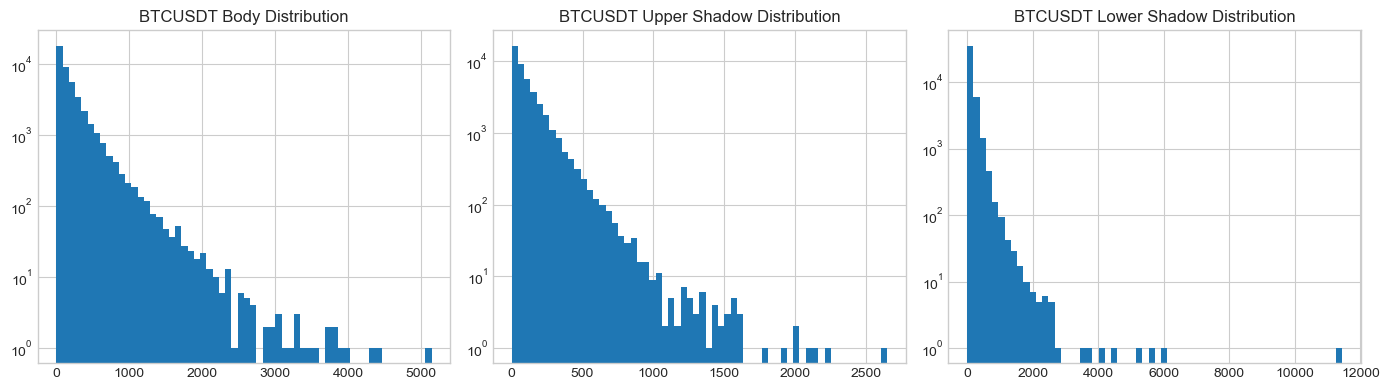

In [12]:
# 4) Candlestick feature sanity checks
# Expect non-negative body/shadows and body <= high-low
sanity_rows = []
for asset, df in processed.items():
    body_nonneg = (df['body'] >= 0).mean()
    up_nonneg = (df['upper_shadow'] >= -1e-12).mean()
    low_nonneg = (df['lower_shadow'] >= -1e-12).mean()
    body_le_range = (df['body'] <= df['hl_range'] + 1e-12).mean()
    sanity_rows.append({
        'asset': asset,
        'body_nonneg_pct': body_nonneg,
        'upper_shadow_nonneg_pct': up_nonneg,
        'lower_shadow_nonneg_pct': low_nonneg,
        'body_le_hl_range_pct': body_le_range,
    })

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)

example_asset = 'BTCUSDT'
ex = processed[example_asset]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(ex['body'], bins=60)
axes[0].set_title(f'{example_asset} Body Distribution')
axes[1].hist(ex['upper_shadow'], bins=60)
axes[1].set_title(f'{example_asset} Upper Shadow Distribution')
axes[2].hist(ex['lower_shadow'], bins=60)
axes[2].set_title(f'{example_asset} Lower Shadow Distribution')
for a in axes:
    a.set_yscale('log')
plt.tight_layout()
plt.show()


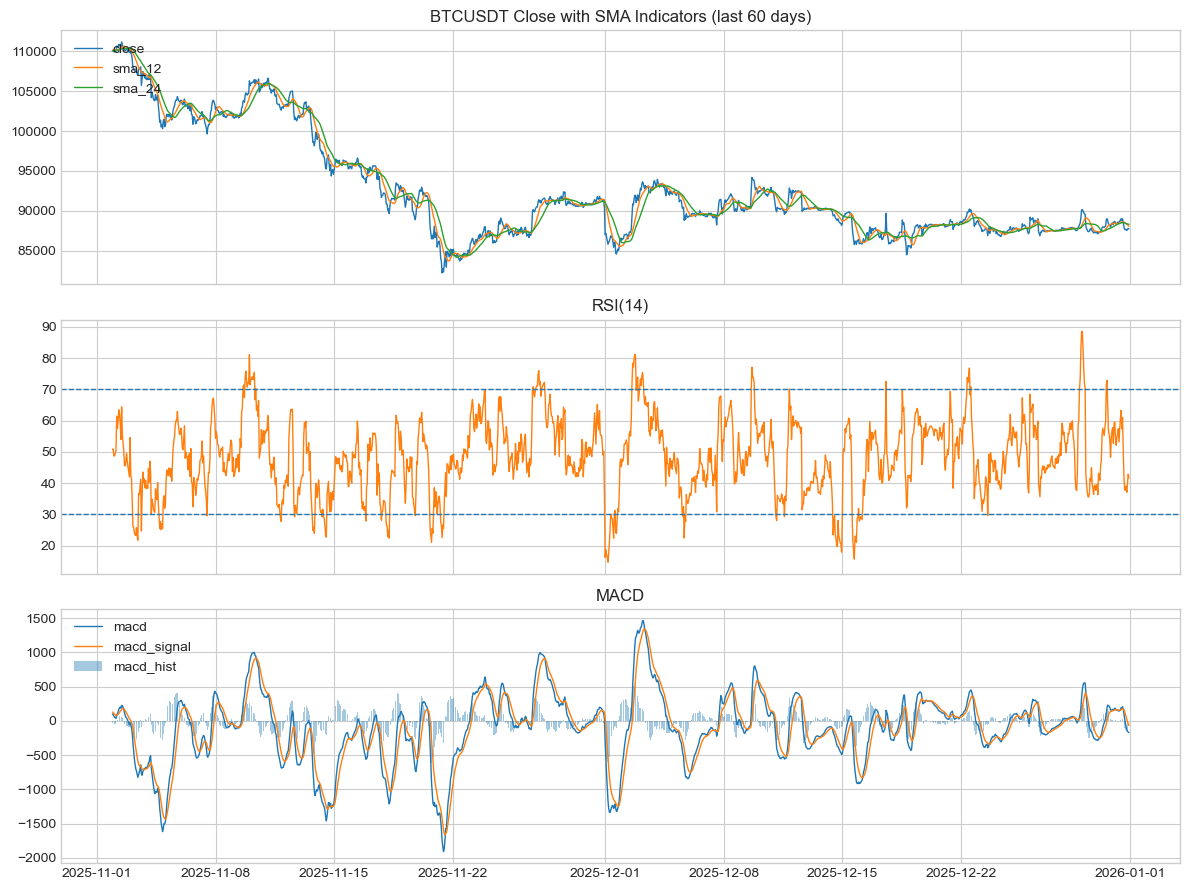

In [13]:
# 5) Technical indicators visual check (BTC sample window)
asset = 'BTCUSDT'
df = processed[asset].copy()
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

# Plot a recent 60-day slice for readability
end_ts = df['timestamp'].max()
start_ts = end_ts - pd.Timedelta(days=60)
view = df[(df['timestamp'] >= start_ts) & (df['timestamp'] <= end_ts)].copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(view['timestamp'], view['close'], label='close', linewidth=1)
axes[0].plot(view['timestamp'], view['sma_12'], label='sma_12', linewidth=1)
axes[0].plot(view['timestamp'], view['sma_24'], label='sma_24', linewidth=1)
axes[0].set_title(f'{asset} Close with SMA Indicators (last 60 days)')
axes[0].legend(loc='upper left')

axes[1].plot(view['timestamp'], view['rsi_14'], color='tab:orange', linewidth=1)
axes[1].axhline(70, linestyle='--', linewidth=1)
axes[1].axhline(30, linestyle='--', linewidth=1)
axes[1].set_title('RSI(14)')

axes[2].plot(view['timestamp'], view['macd'], label='macd', linewidth=1)
axes[2].plot(view['timestamp'], view['macd_signal'], label='macd_signal', linewidth=1)
axes[2].bar(view['timestamp'], view['macd_hist'], width=0.03, alpha=0.4, label='macd_hist')
axes[2].set_title('MACD')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()


,asset,up_rate,non_up_rate
0,BTCUSDT,0.506098,0.493902
1,ETHUSDT,0.506646,0.493354
2,XRPUSDT,0.503997,0.496003
3,SOLUSDT,0.497670,0.502330


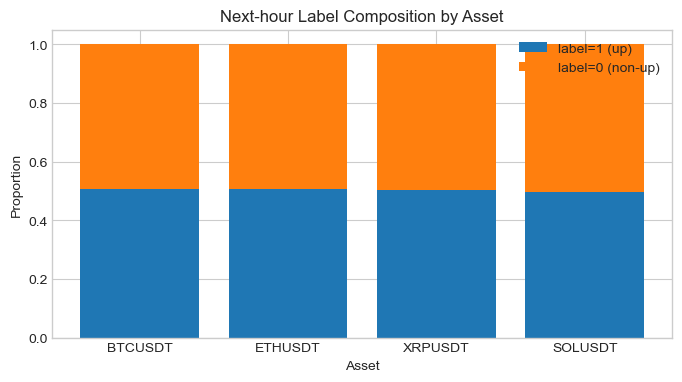

In [14]:
# 6) Label distribution by asset (next-hour up vs non-up)
label_rows = []
for asset, df in processed.items():
    up_rate = df['label_up_1h'].mean()
    label_rows.append({'asset': asset, 'up_rate': up_rate, 'non_up_rate': 1-up_rate})

label_df = pd.DataFrame(label_rows)
display(label_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(label_df['asset'], label_df['up_rate'], label='label=1 (up)')
ax.bar(label_df['asset'], label_df['non_up_rate'], bottom=label_df['up_rate'], label='label=0 (non-up)')
ax.set_title('Next-hour Label Composition by Asset')
ax.set_ylabel('Proportion')
ax.set_xlabel('Asset')
ax.legend()
plt.show()


In [17]:
# Initialize dictionaries to hold the split data
train_data, val_data, test_data = {}, {}, {}

# Define your feature and target columns based on your Step 1 code
feature_cols = [
    'open', 'high', 'low', 'close', 'volume', 'trades',
    'ret_1h', 'log_ret_1h', 'body', 'upper_shadow', 
    'lower_shadow', 'direction', 'hl_range',
    'sma_12', 'sma_24', 'rsi_14', 'macd', 'macd_signal', 'macd_hist'
]
target_col = 'label_up_1h'

for asset, df in processed.items():
    df_clean = df.dropna(subset=feature_cols + [target_col])
    
    n = len(df_clean)
    train_end = int(n * 0.50)
    val_end = int(n * 0.75)
    
    # Chronological slicing (No Shuffling)
    train_data[asset] = df_clean.iloc[:train_end]
    val_data[asset] = df_clean.iloc[train_end:val_end]
    test_data[asset] = df_clean.iloc[val_end:]


In [19]:
def run_logistic_regression(train_df, val_df, asset_name):
    # Separate Features and Target
    X_train, y_train = train_df[feature_cols], train_df[target_col]
    X_val, y_val = val_df[feature_cols], val_df[target_col]
    
    # Scale data (standard practice for Logistic Regression)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Initialize and fit model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_pred)
    
    print(f"--- Logistic Regression: {asset_name} ---")
    print(f"Validation Accuracy: {acc:.4f}")
    
    return {
        'model': model,
        'accuracy': acc,
        'report': classification_report(y_val, y_pred)
    }

# Execute for all assets
results = {}
for asset in ['BTCUSDT', 'ETHUSDT', 'XRPUSDT', 'SOLUSDT']:
    results[asset] = run_logistic_regression(train_data[asset], val_data[asset], asset)

--- Logistic Regression: BTCUSDT ---
Validation Accuracy: 0.5314
--- Logistic Regression: ETHUSDT ---
Validation Accuracy: 0.5419
--- Logistic Regression: XRPUSDT ---
Validation Accuracy: 0.5422
--- Logistic Regression: SOLUSDT ---
Validation Accuracy: 0.5197
